# 03 · Monitoring: reading the concept off the internals

**Phases 7 and 6** — the notebook counterpart of [`experiments/03_monitor.py`](../experiments/03_monitor.py).

Steering *writes* to the residual stream. Monitoring *reads* from it. The paper's proposal is that
the same AGOP eigenbasis that gives you the steering direction also gives you a detector: project
each block's activation onto the top-`P` eigenvectors, train a small logistic probe on those
`6 × 3 = 18` numbers, and you can tell whether the concept is active without looking at the text
at all.

This notebook does two things:

1. **Phase 7** — train those probes and measure AUROC on a held-out test split.
2. **Phase 6** — turn the probe around and use it to re-score the steering sweep from notebook
   `02`, which the lexicon judged so unevenly.

The second part is where this notebook has to be careful with itself, and we come back to that at
the end.

In [1]:
import os, sys, time

_p = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(_p, "rfm_guppy"))
           and os.path.isfile(os.path.join(_p, "requirements.txt"))):
    _parent = os.path.dirname(_p)
    if _parent == _p:
        raise RuntimeError("Run this notebook from inside the repository.")
    _p = _parent
ROOT = _p
sys.path[:0] = [ROOT, os.path.join(ROOT, "guppylm"), os.path.join(ROOT, "notebooks")]

import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

from nbcommon import (CONCEPTS, CONCEPT_COLORS, apply_style,
                      load_activations, load_result, load_vectors)

apply_style()

from rfm_guppy.concepts import load_concept_dataset

ds     = {c: load_concept_dataset(c) for c in CONCEPTS}
vecs   = {c: load_vectors(c) for c in CONCEPTS}
acts   = {c: {s: load_activations(c, s) for s in ("train", "val", "test")} for c in CONCEPTS}
labels = {c: {s: np.array([it["label"] for it in ds[c][s]], dtype=int)
              for s in ("train", "val", "test")} for c in CONCEPTS}
print("loaded", ", ".join(CONCEPTS))

loaded food, valence, env_social


---
## 1 · Features: 18 numbers per prompt

For every block `ℓ` we take the stored top-3 AGOP eigenvectors, subtract the same training mean
that RFM used, apply the same optional L2 normalisation the sweep selected for that block, and
project:

$$x_{\ell p} = \langle a_\ell - \mu_\ell,\; u_{\ell p}\rangle, \qquad p = 1,2,3$$

Keeping the preprocessing identical to training is not a detail — the probe would otherwise be
reading projections on a different scale from the one the eigenvectors were derived in.

A `[n, 384 × 6]` activation tensor becomes `[n, 6, 3]`. That is a **128-fold compression**, and the
whole claim is that nothing about the concept was lost in it.

In [2]:
from rfm_guppy.monitoring import build_probe_features

feats = {c: {s: build_probe_features(acts[c][s], vecs[c]["eigvecs_top3"],
                                     vecs[c]["input_mean"], vecs[c]["hp_normalize"])
             for s in ("train", "val", "test")} for c in CONCEPTS}

for c in CONCEPTS:
    print(f"{c:11s}  {acts[c]['test'].shape} → {feats[c]['test'].shape}   "
          f"({np.prod(acts[c]['test'].shape[1:])} → {np.prod(feats[c]['test'].shape[1:])} features)")

food         (120, 6, 384) → (120, 6, 3)   (2304 → 18 features)
valence      (40, 6, 384) → (40, 6, 3)   (2304 → 18 features)
env_social   (120, 6, 384) → (120, 6, 3)   (2304 → 18 features)


### Is it separable before we fit anything?

The cheapest sanity check: plot the first two AGOP projections of the **test** split at each
concept's best block. If the paper's picture is right these should fall into two clouds without
any classifier being involved.

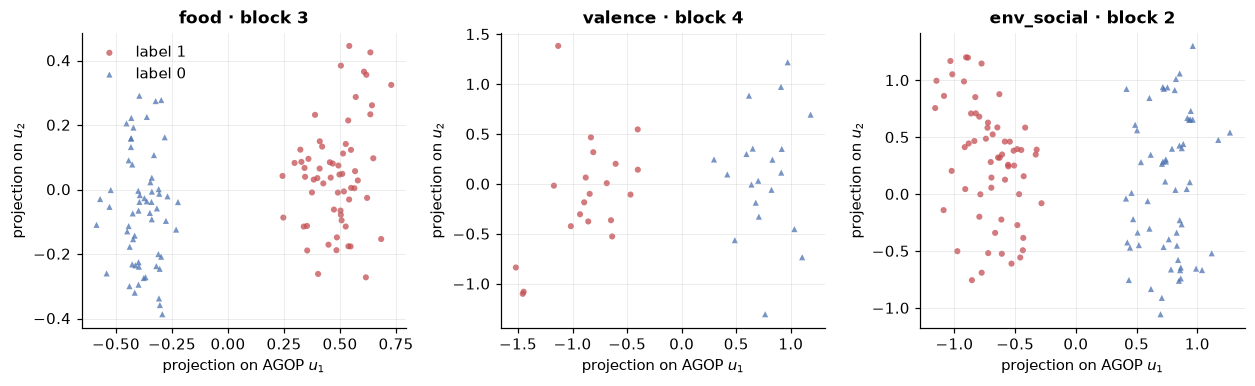

single-eigenvector test AUROC (best RFM block):
  food        blk3   u1=1.000   u2=0.679   u3=0.519
  valence     blk4   u1=1.000   u2=0.617   u3=0.645
  env_social  blk2   u1=1.000   u2=0.599   u3=0.705


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
for ax, c in zip(axes, CONCEPTS):
    blk = int(np.argmax(vecs[c]["val_abs_rho"]))
    X, y = feats[c]["test"][:, blk, :], labels[c]["test"]
    for lab, mark, col in [(1, "o", "#C44E52"), (0, "^", "#4C72B0")]:
        m = y == lab
        ax.scatter(X[m, 0], X[m, 1], s=16, marker=mark, alpha=0.75, color=col,
                   label=f"label {lab}", edgecolors="none")
    ax.set_title(f"{c} · block {blk}")
    ax.set_xlabel("projection on AGOP $u_1$"); ax.set_ylabel("projection on $u_2$")
axes[0].legend()
plt.tight_layout(); plt.show()

# How much does each individual eigenvector carry on its own?
from sklearn.metrics import roc_auc_score
sym = lambda a: max(a, 1 - a)
print("single-eigenvector test AUROC (best RFM block):")
for c in CONCEPTS:
    blk = int(np.argmax(vecs[c]["val_abs_rho"]))
    a = [sym(roc_auc_score(labels[c]["test"], feats[c]["test"][:, blk, p])) for p in range(3)]
    print(f"  {c:11s} blk{blk}   u1={a[0]:.3f}   u2={a[1]:.3f}   u3={a[2]:.3f}")

The first AGOP eigenvector — the concept vector itself — separates the classes perfectly on the
horizontal axis alone (`u₁` reaches AUROC 1.000 unaided on all three concepts). The second and
third are much weaker but **not** empty: 0.60–0.71, above chance. So the picture is not quite the
strict rank-1 story the eigenvalue spectra suggested — the trailing eigenvectors carry a little
residual class signal, which is presumably why the aggregate probe is built on three of them
rather than one.

---
## 2 · The probes

Two strategies, both plain logistic regression with a standardiser in front and `C` swept on
validation:

- **per-block** — 3 features, one probe per block, telling us *where* in the stack the concept is
  most legible;
- **aggregate** — all 18 features at once.

In [4]:
from rfm_guppy.monitoring import train_probes, evaluate_probes_on_test

probes, tests = {}, {}
for c in CONCEPTS:
    print(f"\n{c}")
    probes[c] = train_probes(feats[c]["train"], labels[c]["train"],
                             feats[c]["val"],   labels[c]["val"])
    tests[c]  = evaluate_probes_on_test(probes[c], feats[c]["test"], labels[c]["test"])


food


    blk 0: val AUROC = 0.9983
    blk 1: val AUROC = 1.0000
    blk 2: val AUROC = 1.0000
    blk 3: val AUROC = 1.0000
    blk 4: val AUROC = 1.0000
    blk 5: val AUROC = 1.0000
    aggregate (18 features): val AUROC = 1.0000

valence
    blk 0: val AUROC = 0.9125
    blk 1: val AUROC = 1.0000
    blk 2: val AUROC = 1.0000
    blk 3: val AUROC = 1.0000
    blk 4: val AUROC = 1.0000
    blk 5: val AUROC = 1.0000
    aggregate (18 features): val AUROC = 1.0000

env_social
    blk 0: val AUROC = 0.9394
    blk 1: val AUROC = 1.0000
    blk 2: val AUROC = 1.0000
    blk 3: val AUROC = 1.0000
    blk 4: val AUROC = 1.0000
    blk 5: val AUROC = 1.0000
    aggregate (18 features): val AUROC = 1.0000


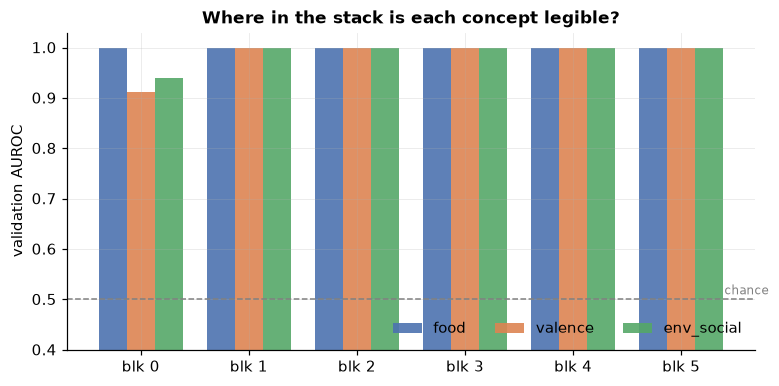

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
w, xs = 0.26, np.arange(6)
for i, c in enumerate(CONCEPTS):
    ax.bar(xs + (i - 1) * w, probes[c]["per_block_val_auroc"], w,
           color=CONCEPT_COLORS[c], label=c, alpha=0.9)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.text(5.4, 0.51, "chance", color="gray", fontsize=8)
ax.set_xticks(xs, [f"blk {i}" for i in range(6)])
ax.set_ylim(0.4, 1.03); ax.set_ylabel("validation AUROC")
ax.set_title("Where in the stack is each concept legible?")
ax.legend(ncol=3, loc="lower right")
plt.tight_layout(); plt.show()

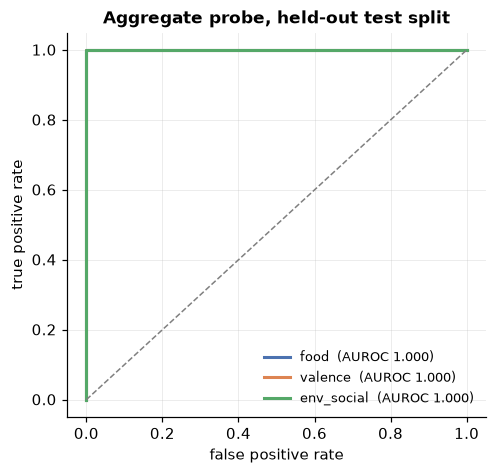

,best block,val AUROC (best blk),test AUROC (best blk),val AUROC (aggregate),test AUROC (aggregate)
concept,,,,,
food,1,1.0000,1.0000,1.0000,1.0000
valence,1,1.0000,1.0000,1.0000,1.0000
env_social,1,1.0000,1.0000,1.0000,1.0000


In [6]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
for c in CONCEPTS:
    fpr, tpr, _ = roc_curve(labels[c]["test"], np.array(tests[c]["agg_test_probs"]))
    ax.plot(fpr, tpr, lw=2, color=CONCEPT_COLORS[c],
            label=f'{c}  (AUROC {tests[c]["aggregate_test_auroc"]:.3f})')
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="gray")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("Aggregate probe, held-out test split")
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout(); plt.show()

rows = [{"concept": c,
         "best block": probes[c]["best_block"],
         "val AUROC (best blk)":  f'{probes[c]["best_block_val_auroc"]:.4f}',
         "test AUROC (best blk)": f'{tests[c]["best_block_test_auroc"]:.4f}',
         "val AUROC (aggregate)":  f'{probes[c]["aggregate_val_auroc"]:.4f}',
         "test AUROC (aggregate)": f'{tests[c]["aggregate_test_auroc"]:.4f}'} for c in CONCEPTS]
pd.DataFrame(rows).set_index("concept")

**Every curve is a right angle.** AUROC = 1.000 on held-out data for all three concepts — the
probe never once ranks a negative above a positive.

That is a ceiling, and a ceiling is not the same as a strong result. Three things make it easy:
the concepts are the model's *own* training categories rather than emergent properties; the test
splits are small (40–120 examples); and the classes are drawn from disjoint, clearly distinct
category groups. A perfect score here says the linear-readout mechanism is intact at 8.7M
parameters. It says nothing about how the method behaves on a genuinely hard concept, because we
never presented one.

In [7]:
committed = load_result("monitor_auroc.json")
rows = []
for c in CONCEPTS:
    a = tests[c]["aggregate_test_auroc"]; b = committed[c]["aggregate_test_auroc"]
    rows.append({"concept": c, "notebook": f"{a:.6f}", "results/monitor_auroc.json": f"{b:.6f}",
                 "Δ": f"{abs(a-b):.2e}"})
    assert abs(a - b) < 1e-9, f"{c} diverged from the committed run"
print("✓ probes retrained here reproduce results/monitor_auroc.json exactly\n")
pd.DataFrame(rows).set_index("concept")

✓ probes retrained here reproduce results/monitor_auroc.json exactly



,notebook,results/monitor_auroc.json,Δ
concept,,,
food,1.000000,1.000000,0.00e+00
valence,1.000000,1.000000,0.00e+00
env_social,1.000000,1.000000,0.00e+00


---
## 3 · Phase 6 — scoring the steering sweep with the probe

Now the probe is pointed at notebook `02`'s generations. Each steered output is re-assembled into
a full ChatML exchange — the original probe prompt as the user turn, the steered text as the
assistant turn — so the probe sees the same format as its training data, and then scored.

A generation counts as a **success** if the probe's probability exceeds 0.5 **or** the lexicon
fires. The results below are the committed Phase 6 output; rerunning it needs the model and a few
minutes.

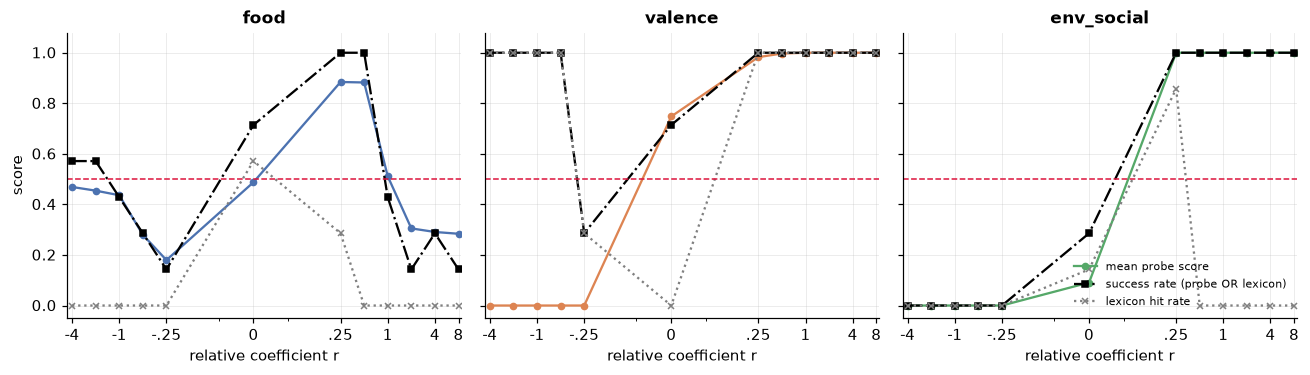

,baseline success (r=0),best +r,success at best +r
concept,,,
food,71%,0.25,100%
valence,71%,0.25,100%
env_social,29%,0.25,100%


In [8]:
ev = {c: load_result(f"eval6_{c}.json") for c in CONCEPTS}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, c in zip(axes, CONCEPTS):
    rs   = sorted(float(k) for k in ev[c]["eval_per_r"])
    get  = lambda key: [ev[c]["eval_per_r"][str(r)][key] for r in rs]
    ax.plot(rs, get("mean_probe_score"),      marker="o", ms=4, color=CONCEPT_COLORS[c],
            label="mean probe score")
    ax.plot(rs, get("steering_success_rate"), marker="s", ms=4, ls="-.", color="black",
            label="success rate (probe OR lexicon)")
    ax.plot(rs, get("lexicon_hit_rate"),      marker="x", ms=4, ls=":", color="gray",
            label="lexicon hit rate")
    ax.axhline(0.5, color="crimson", ls="--", lw=1)
    ax.set_xscale("symlog", linthresh=0.25)
    ax.set_xticks([-4, -1, -0.25, 0, 0.25, 1, 4, 8])
    ax.set_xticklabels(["-4", "-1", "-.25", "0", ".25", "1", "4", "8"])
    ax.set_xlabel("relative coefficient r"); ax.set_title(c)
axes[0].set_ylabel("score"); axes[0].set_ylim(-0.05, 1.08)
axes[-1].legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); plt.show()

pd.DataFrame([{"concept": c,
               "baseline success (r=0)": f'{ev[c]["baseline_success_rate"]:.0%}',
               "best +r": ev[c]["best_r_pos"],
               "success at best +r": f'{ev[c]["best_success_rate"]:.0%}'} for c in CONCEPTS]
            ).set_index("concept")

### The probe is far more generous than the lexicon — and that is the problem

By this metric every concept goes to **100% success at `r = +0.25`**, including `food`, whose
lexicon hit rate *fell* at that exact coefficient, and whose generations at that coefficient are
the barely-grammatical *"whole palate palate palate promise…"* strings from notebook `02`.

Both measurements are correct about different things:

- the **lexicon** asks *did the model say a concept word*, and answers no;
- the **probe** asks *did the activations move along the concept direction*, and answers
  emphatically yes.

The activations did move — we pushed them there ourselves. So the Phase 6 metric is **partially
circular**: the probe reads the top AGOP eigenvectors, and the steering vector *is* the top AGOP
eigenvector. Adding `ε·v_ℓ` to the stream moves the very projection the probe thresholds, whether
or not the text changed in any way a reader would recognise as the concept.

In fairness to the probe, it is not merely reacting to *being perturbed*: its score tracks the
**sign** of `r` on every concept — `valence` and `env_social` fall to exactly 0.00 under negative
steering and sit at 1.00 under positive steering, and even `food`, the one concept whose baseline
is already half-active, separates 0.18–0.47 (negative) from 0.88 (at `r = +0.25`). It genuinely
reads direction. What it cannot do is notice that the
sentence carrying that direction stopped being a sentence.

This is stated as a limitation in [`results/REPORT.md`](../results/REPORT.md), and it is worth
being blunt about here: **the 100% steering-success number is not independent evidence that
steering works.** The honest reading of notebooks `02` and `03` together is that the direction is
causal but the behavioural effect at this scale is crude, and only an external judge — which a
4,096-token fish vocabulary cannot supply — would settle it.

---
## What this phase established

| Claim under test | Verdict |
|---|---|
| The concept is linearly readable from the AGOP eigenbasis | **Yes** — AUROC 1.000 on held-out data, from 18 numbers per prompt |
| The compression to `6 × 3` projections preserves the concept | **Yes** — 2,304 → 18 features with no loss of separability |
| The result is a strong test of the method | **No** — a ceiling on in-domain concepts with 40–120 test examples |
| Probe-scored steering success is independent evidence | **No** — the probe reads the direction the steering wrote to |

Next: [`04_baselines.ipynb`](04_baselines.ipynb) asks whether RFM was needed at all, or whether
three much simpler estimators find the same direction.